First, we need to load the necessary libraries

In [1]:
import pandas as pd # Used for data manipulation
import numpy as np # Used for numerical operations
import matplotlib.pyplot as plt # Used for plotting
import spacy # Used for text preprocessing and NLP tasks
from spacy import displacy # Used for visualizing NER results
from wordcloud import WordCloud # Used for creating word clouds
from gensim.corpora.dictionary import Dictionary # Used for creating a dictionary of tokens and their corresponding ids
from gensim.models.ldamodel import LdaModel # Used for training a Latent Dirichlet Allocation (LDA) topic model
from gensim.models import CoherenceModel # Used for evaluating the coherence of the topics generated by the LDA model
import pyLDAvis.gensim_models # Used for visualizing LDA topic models

We also need to download the spaCy English model for NER. This only needs to be done once

In [2]:
#!python -m spacy download en_core_web_sm

Then, we download a dataset of central bank speeches. We are using the dataset from [cbspeeches.com](https://cbspeeches.com/) [@Campiglio2025], which contains a collection of speeches by central bankers from around the world.

In [3]:
import urllib.request
import os.path

# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Check if the file exists
if not os.path.isfile("data/CBS_dataset_v1.0.dta"):

    print("Downloading dataset...")

    # Define the dataset to be downloaded
    fileurl = "https://www.dropbox.com/scl/fi/la5hpz39yht8mmoz0n98t/CBS_dataset_v1.0.dta?rlkey=jo0u8ktm1ixkwic4jw03re9c6&dl=1"

    # Define the filename to save the dataset
    filename = "data/CBS_dataset_v1.0.dta"

    # Download the dataset in the data folder
    urllib.request.urlretrieve(fileurl, filename)

    print("DONE!")

else:

    print("Dataset already downloaded!")

Dataset already downloaded!


Then, we load the dataset into a pandas DataFrame

In [4]:
speeches = pd.read_stata("data/CBS_dataset_v1.0.dta")
speeches = speeches.set_index("index")

### Data Exploration

Let's take a look at the dataset structure

In [5]:
speeches.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35487 entries, 0 to 35486
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   URL            35487 non-null  object
 1   PDF            35487 non-null  object
 2   Title          35487 non-null  object
 3   Subtitle       35487 non-null  object
 4   Date           35487 non-null  object
 5   Authorname     35487 non-null  object
 6   Role           35487 non-null  object
 7   Gender         35487 non-null  object
 8   CentralBank    35487 non-null  object
 9   Country        35487 non-null  object
 10  text           35487 non-null  object
 11  text_original  35487 non-null  object
 12  Filename       35487 non-null  object
 13  Language       35487 non-null  object
 14  Source         35487 non-null  object
dtypes: object(15)
memory usage: 4.2+ MB


We can see that we have a DataFrame with several columns, including the speech text, date, speaker, and title. Before we continue, let's convert the `Date` column to a datetime format for easier manipulation later on

In [6]:
speeches["Date"] = pd.to_datetime(speeches["Date"])

Now, let's preview the dataset

In [7]:
speeches.head()

,URL,PDF,Title,Subtitle,Date,Authorname,Role,Gender,CentralBank,Country,text,text_original,Filename,Language,Source
index,,,,,,,,,,,,,,,
0,https://www.cbaruba.org/readBlob.do?id=10756,,President speech Managing the Economy as if th...,,2021-12-08,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,Managing the Economy as if the Future Really M...,,abw_10756,English,CB websites
1,https://www.cbaruba.org/readBlob.do?id=7515,,Speech President of the CBA 4th Annual Future ...,,2019-11-01,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,Safeguarding our Future: Strategies for an Aru...,,abw_7515,English,CB websites
2,https://www.cbaruba.org/readBlob.do?id=7518,,Speech Symposium President Semeleer CBA,,2019-09-06,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,FOSTERING ECONOMIC RESILIENCE IN ARUBA; FROM R...,,abw_7518,English,CB websites
3,https://www.cbaruba.org/readBlob.do?id=7548,,Integrity Koninkrijk Seminar,,2016-10-28,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,"Presentation by Mrs Jeanette R. Semeleer, Pres...","Voordracht door mevrouw Jeanette R. Semeleer, ...",abw_7548,Dutch,CB websites
4,https://www.cbaruba.org/readBlob.do?id=7554,,Speech by the President at the BES seminar hel...,,2010-03-29,Jeanette R Semeleer,Governor,Female,Central Bank of Aruba,ABW,Ongoing changes in the supervisory landscape a...,,abw_7554,English,CB websites


Let's look at the first speech in detail

In [8]:
idx = 0  # index of the speech to display
max_len = 200  # maximum length of text to display

for column in ["Title", "Authorname", "CentralBank", "Date", "text", "URL"]:

    # Get the data and truncate if it is too long
    data = speeches.iloc[idx][column]
    data = (data[:max_len] + "...") if isinstance(data, str) and len(data) > max_len else data

    # Print the column name and data
    print(f"{column}: {data}\n")

Title: President speech Managing the Economy as if the Future Really Matters Business Day at the CBA

Authorname: Jeanette R Semeleer

CentralBank: Central Bank of Aruba

Date: 2021-12-08 00:00:00

text: Managing the Economy as if the Future Really Matters Speech by the President of the Centrale Bank van Aruba Business Day at the CBA December 8 & 9, 2021 Slide it 3 Ladies and gentlemen, To say that 20...

URL: https://www.cbaruba.org/readBlob.do?id=10756



Let's check which central banks are most represented in the dataset

<Axes: xlabel='CentralBank'>

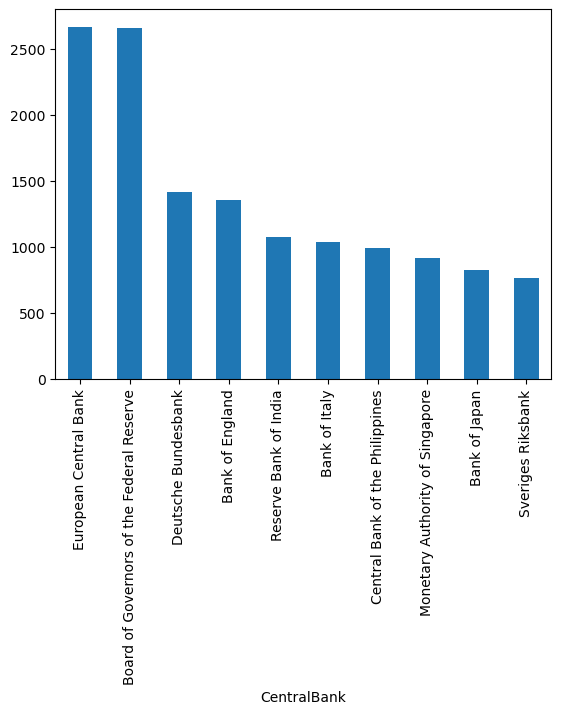

In [9]:
speeches["CentralBank"].value_counts().head(10).plot(kind="bar")

There are more than 2500 speeches for both the ECB and the Fed. We can also check the distribution of speeches over time

<Axes: xlabel='Date'>

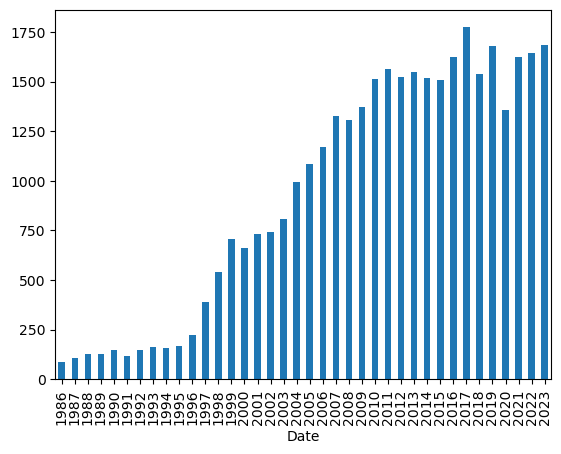

In [10]:
speeches["Date"].dt.year.value_counts().sort_index().plot(kind="bar")

Let's quickly recap what this last line did

1. We accessed the `Date` column of the `speeches` DataFrame, which contains the dates of the speeches.

2. We used the `dt.year` accessor to extract the year from each date in the `Date` column.

3. We then called `value_counts()` to count the number of speeches for each year.

4. We used `sort_index()` to sort the counts by year in chronological order.

5. Finally, we called `plot(kind='bar')` to create a bar chart of the number of speeches per year.


Let's take a look at the distribution of speeches by central bank and year

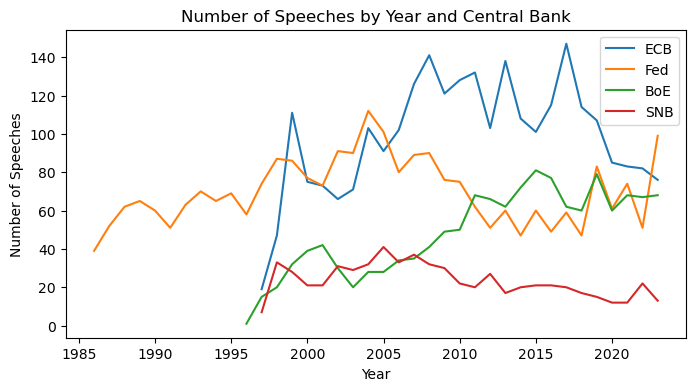

In [11]:
fig = plt.figure(figsize=(8, 4))
plt.plot(speeches.query("CentralBank == 'European Central Bank'")["Date"].dt.year.value_counts().sort_index(), label="ECB")
plt.plot(speeches.query("CentralBank == 'Board of Governors of the Federal Reserve'")["Date"].dt.year.value_counts().sort_index(), label="Fed")
plt.plot(speeches.query("CentralBank == 'Bank of England'")["Date"].dt.year.value_counts().sort_index(), label="BoE")
plt.plot(speeches.query("CentralBank == 'Swiss National Bank'")["Date"].dt.year.value_counts().sort_index(), label="SNB")
plt.xlabel("Year")
plt.ylabel("Number of Speeches")
plt.title("Number of Speeches by Year and Central Bank")
plt.legend()
plt.show()

Here we used a different approach to plot the number of speeches by year and central bank. We created a figure with a specific size, then plotted the number of speeches for each central bank separately using `plt.plot()`. We also added labels for the axes, a title, and a legend to differentiate between the central banks. Finally, we displayed the plot using `plt.show()`.

Let's try to get a sense of the content of the speeches. We will focus on the ECB speeches for this part. We can create a word cloud to visualize the most common words in the ECB speeches. We first concatenate all the speech texts into a single string

We first filter the dataset to only include ECB speeches

In [12]:
ecb_speeches = speeches.query("CentralBank == 'European Central Bank'").copy()
ecb_speeches.head()

,URL,PDF,Title,Subtitle,Date,Authorname,Role,Gender,CentralBank,Country,text,text_original,Filename,Language,Source
index,,,,,,,,,,,,,,,
2976,https://www.ecb.europa.eu/press/key/date/2000/...,,One year with the euro,"Speech delivered by Dr Sirkka Hmlinen, Mem...",2000-01-08,Sirkka Hmlinen,Board member,Female,European Central Bank,ECB,One year with the euro Speech delivered by Dr ...,,ecb_000108.en,English,CB websites
2977,https://www.ecb.europa.eu/press/key/date/2000/...,,Opening Remarks at a Hearing of the Committee ...,"Professor Otmar Issing, Member of the Board o...",2000-01-10,Otmar Issing,Board member,Male,European Central Bank,ECB,Opening Remarks at a Hearing of the Committee ...,,ecb_000110.en,English,CB websites
2978,https://www.ecb.europa.eu/press/key/date/2000/...,,The international impact of the euro,"Speech delivered by Christian Noyer, Vice...",2000-01-13,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,The international impact of the euro Speech de...,,ecb_000113.en,English,BIS
2979,https://www.ecb.europa.eu/press/key/date/2000/...,,The role of the central bank in encouraging an...,"Speech given by Christian Noyer, Vice-Pres...",2000-01-21,Christian Noyer,Deputy Governor,Male,European Central Bank,ECB,The role of the central bank in encouraging an...,,ecb_000121.en,English,BIS
2980,https://www.ecb.europa.eu/press/key/date/2000/...,,The euro area - first experience and perspectives,"by Professor Otmar Issing, Member of the Boar...",2000-01-26,Otmar Issing,Board member,Male,European Central Bank,ECB,The euro area - first experience and perspecti...,,ecb_000126.en,English,CB websites


Then, we can create a word cloud to visualize the most common words in the ECB speeches. We first concatenate all the speech texts into a single string

In [13]:
text = " ".join(ecb_speeches["text"])

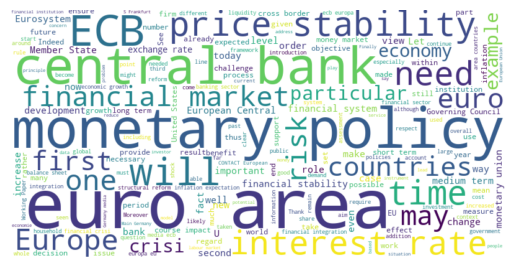

In [14]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

There are some common words that show up in many speeches such as "ECB", and "central bank". Let's exclude them by expanding the list of stopwords

In [15]:
w = WordCloud()
stopwords = list(w.stopwords)
custom_stopwords = ["ECB", "central bank", "central", "bank", "european", "monetary policy", "monetary", "policy", "will", "euro", "area"]
stopwords = set(stopwords + custom_stopwords)

The word cloud now looks a bit different, with more specific terms. This gives us a better sense of the topics that are being discussed in the ECB speeches.

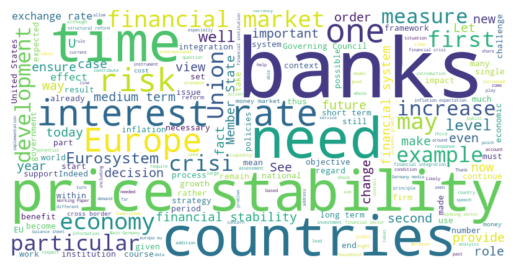

In [16]:
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords).generate(text)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Let's see how this changed over time. We can create separate word clouds for different time periods

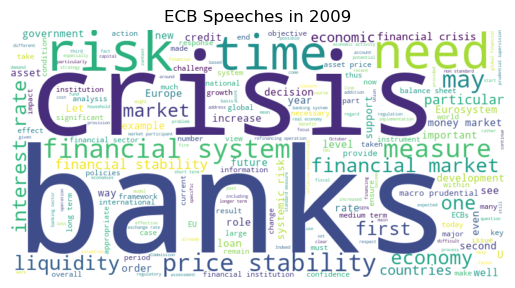

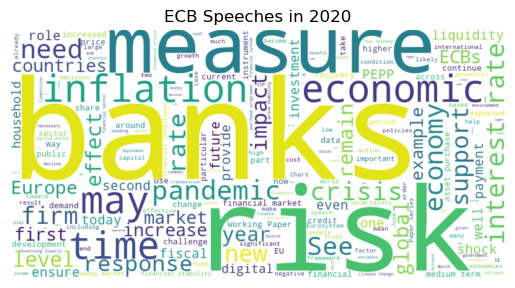

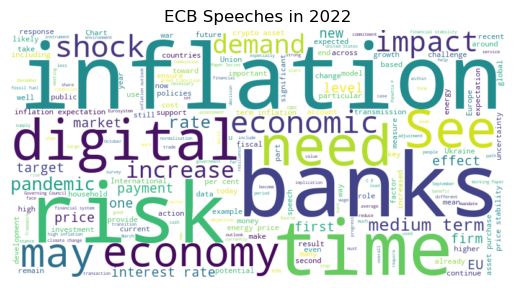

In [17]:
for year in [2009, 2020, 2022]:
    text = " ".join(ecb_speeches.query("Date.dt.year == @year")["text"])
    wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords).generate(text)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"ECB Speeches in {year}")
    plt.show()

These word clouds give us a sense of how the focus of the ECB speeches has evolved over time. For example, we can see that in 2009, during the global financial crisis, there was a lot of discussion about "crisis", "banks", and "risk". In contrast, in 2020, there is more discussion about "risk", "banks", and "pandemic". And in 2022, "inflation" has become a more prominent topic.


### Text Preprocessing

Now that we have a better understanding of the dataset, we can start preprocessing the text data. This typically involves several steps, such as tokenization, stopword removal, and stemming or lemmatization. We will use the spaCy library for these tasks.

In [18]:
# Load the spaCy English model
nlp = spacy.load("en_core_web_sm")

Let's take a look at how to preprocess a single speech. We will start with tokenization, which is the process of breaking down the text into individual words or tokens.

In [19]:
# Get the text of the first speech
text = ecb_speeches.iloc[0]["text"]

# Process the text using spaCy
doc = nlp(text)

# Extract the tokens
tokens = [token.text for token in doc]

# Print the speech text and the first 10 tokens
print(f"{text[:80]}...")  # Print the first 80 characters of the speech

# Print the first 10 tokens
print(tokens[0:14])

One year with the euro Speech delivered by Dr Sirkka Hamalainen, Member of the E...
['One', 'year', 'with', 'the', 'euro', 'Speech', 'delivered', 'by', 'Dr', 'Sirkka', 'Hamalainen', ',', 'Member', 'of']


Spacy does a lot more than just tokenization. It also performs part-of-speech tagging, named entity recognition, and more. We can access all of this information through the `doc` object. For example, we can extract the lemmas of the tokens, which are the base forms of the words

In [20]:
lemmas = [token.lemma_ for token in doc]
print(lemmas[0:14])

['one', 'year', 'with', 'the', 'euro', 'Speech', 'deliver', 'by', 'Dr', 'Sirkka', 'Hamalainen', ',', 'Member', 'of']


We will also see how to use spaCy for named entity recognition (NER) and dependency parsing later on. For now, let's focus on the basic text preprocessing steps of tokenization, stopword removal, and lemmatization.

Let's write a function to preprocess the text of all the speeches in the dataset. This function will perform tokenization, stopword removal, and lemmatization

In [21]:
custom_stopwords = [] # You can add any additional stopwords that you want to exclude from the analysis

def preprocess_texts(texts):

    # Replace European Central Bank with ECB to avoid it being split into multiple tokens
    texts_np = np.char.replace(texts.values.astype(str), "European Central Bank", "ECB")

    # Convert the numpy array of texts to a list of strings
    text_list = texts_np.tolist()

    # Process each text using spaCy
    docs = nlp.pipe(text_list, disable=["tok2vec", "parser", "ner"]) # We disable the components that we don't need to speed up the processing

    tokens_list = []

    for doc in docs:

        # Extract the lemmas of the tokens, lowercase them and exclude stopwords, punctuation, numbers, and custom stopwords
        lemmas = [token.lemma_.lower() for token in doc 
            if not token.is_stop and 
            not token.is_punct and 
            not token.like_num and
            token.text not in custom_stopwords
        ]

        tokens_list.append(lemmas)

    return pd.Series(tokens_list, index=texts.index)

We could do more preprocessing steps, but we will keep it simple for now. We can always come back and add more steps later if needed. Let's try our function on a single speech to see how it works. 

We need to define a wrapper function to preprocess a single text, since our `preprocess_texts` function is designed to work with a Series of texts

In [22]:
def preprocess_text(text):
    return preprocess_texts(pd.Series([text]))[0]

Then, we can apply this function to the first speech in the dataset

In [23]:
preprocessed_tokens = preprocess_text(ecb_speeches.iloc[0]["text"])

for i in range(14):
    print(f"{preprocessed_tokens[i]}")

year
euro
speech
delivered
dr
sirkka
hamalainen
member
executive
board
ecb
europaisches
wochenende
berlin


Let's compare the preprocessed tokens with the original text to see how the function has transformed the text

In [24]:
print("Original tokens:")
print(tokens[0:14])

print("\nPreprocessed tokens:")
print(preprocessed_tokens[0:14])

print(f"\nNumber of original tokens: {len(tokens)}")
print(f"Number of preprocessed tokens: {len(preprocessed_tokens)}")
print(f"Number of unique original tokens: {len(set(tokens))}")
print(f"Number of unique preprocessed tokens: {len(set(preprocessed_tokens))}")

Original tokens:
['One', 'year', 'with', 'the', 'euro', 'Speech', 'delivered', 'by', 'Dr', 'Sirkka', 'Hamalainen', ',', 'Member', 'of']

Preprocessed tokens:
['year', 'euro', 'speech', 'delivered', 'dr', 'sirkka', 'hamalainen', 'member', 'executive', 'board', 'ecb', 'europaisches', 'wochenende', 'berlin']

Number of original tokens: 3132
Number of preprocessed tokens: 1388
Number of unique original tokens: 857
Number of unique preprocessed tokens: 653


Let's apply this preprocessing function to all the speeches in the dataset. We will create a new column in the DataFrame to store the preprocessed tokens

In [25]:
ecb_speeches["preprocessed_tokens"] = preprocess_texts(ecb_speeches["text"])

Then, we can take a look at the preprocessed tokens

In [26]:
ecb_speeches["preprocessed_tokens"]

index
2976     [year, euro, speech, delivered, dr, sirkka, ha...
2977     [opening, remarks, hearing, committee, economi...
2978     [international, impact, euro, speech, delivere...
2979     [role, central, bank, encouraging, safeguardin...
2980     [euro, area, experience, perspectives, profess...
                               ...                        
28610    [mr, duisenberg, reports, outcome, latest, mee...
28657    [mr, duisenbergs, statement, european, unions,...
28681    [mr, duisenberg, reports, outcome, latest, mee...
28705    [mr, duisenberg, mr, noyer, report, outcome, l...
28731    [mr, duisenberg, reports, outcome, latest, mee...
Name: preprocessed_tokens, Length: 2665, dtype: object

Let's check how many unique tokens we have in the preprocessed speeches

In [27]:
unique_tokens = set()
for tokens in ecb_speeches["preprocessed_tokens"]:
    unique_tokens.update(tokens)
print(f"Number of unique tokens in preprocessed speeches: {len(unique_tokens)}")

Number of unique tokens in preprocessed speeches: 57772


There are still a lot of unique tokens. We can also check the most common tokens in the preprocessed speeches

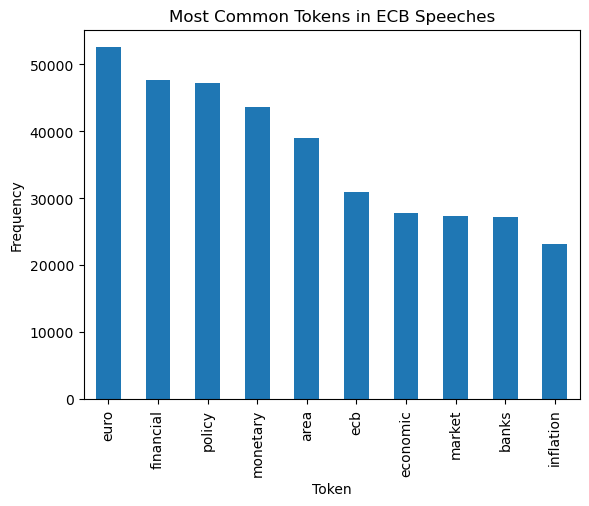

In [28]:
# Flatten the Series of preprocessed tokens using a list comprehension
all_tokens = [token for tokens in ecb_speeches["preprocessed_tokens"] for token in tokens]

# Create a Series of all tokens and count the frequency of each token
all_tokens_series = pd.Series(all_tokens)
token_counts = all_tokens_series.value_counts()

# Plot the 10 most common tokens
token_counts.head(10).plot(kind="bar")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Most Common Tokens in ECB Speeches")
plt.show()

With the preprocessed tokens, we can now move on to the next steps of our NLP pipeline, such as creating text representations, performing text classification, or applying topic modeling techniques.

:::{.callout-note}

#### N-Grams

We have not taken advantage of n-grams in our preprocessing function. N-grams are sequences of n tokens that can capture more context than individual tokens. For example, bigrams (n=2) can capture common phrases like "monetary policy" or "interest rates". We could modify our preprocessing function to include n-grams if we wanted to capture more context in the speeches.

The downside of using n-grams is that it can lead to a much larger number of unique tokens, which can make the analysis more complex and computationally expensive. Therefore, it is often a trade-off between capturing more context and keeping the number of unique tokens manageable.

:::


### Topic Modeling

With the preprocessed tokens, we can now apply topic modeling techniques to uncover the underlying themes in the ECB speeches. One of the most popular topic modeling algorithms is Latent Dirichlet Allocation (LDA), which is a generative probabilistic model that assumes that each document is a mixture of topics and each topic is a mixture of words.

To apply LDA, we first need to create a dictionary of tokens and their corresponding ids, and then create a corpus of documents represented as bag-of-words vectors. We can use the `gensim` library to do this

In [29]:
dictionary = Dictionary(ecb_speeches["preprocessed_tokens"].to_list())

In [30]:
for token, token_id in dictionary.token2id.items():
    print(f"Token: {token}, Token ID: {token_id}")

    if token_id == 10:
        break

Token: able, Token ID: 0
Token: acceptance, Token ID: 1
Token: access, Token ID: 2
Token: accounted, Token ID: 3
Token: achieve, Token ID: 4
Token: achieved, Token ID: 5
Token: achievement, Token ID: 6
Token: achieving, Token ID: 7
Token: action, Token ID: 8
Token: active, Token ID: 9
Token: addition, Token ID: 10


The dictionary maps each unique token to a unique id. We can check how many unique tokens we have in the dictionary

In [31]:
print(f"Number of unique tokens in the dictionary: {len(dictionary.token2id)}")

Number of unique tokens in the dictionary: 57772


To reduce the number of tokens, we can filter out tokens that appear in less than 5 speeches or more than 50% of the speeches, and keep only the top 1000 most frequent tokens

In [32]:
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=1000)

After filtering, we should have fewer unique tokens in the dictionary

In [33]:
print(f"Number of unique tokens after filtering: {len(dictionary.token2id)}")

Number of unique tokens after filtering: 1000


Next, we need to create a corpus of documents represented as bag-of-words vectors. Each document will be represented as a list of tuples, where each tuple contains the token id and the token count in the document

In [34]:
corpus = [dictionary.doc2bow(doc) for doc in ecb_speeches["preprocessed_tokens"].to_list()]

We can access the bag-of-words representation of the first document in the corpus

In [35]:
corpus[0][0:10]  # We only print the first 10 token ids and counts to avoid printing the entire list

[(0, 1),
 (1, 2),
 (2, 1),
 (3, 2),
 (4, 1),
 (5, 1),
 (6, 1),
 (7, 1),
 (8, 1),
 (9, 1)]

Let's convert the bag-of-words representation back to the original tokens to see how it works

In [36]:
# Get the token ids and counts for the first document
token_ids_counts = corpus[0][0:10] # We only take the first 10 token ids and counts to avoid printing the entire list

# Convert the token ids back to tokens and print them with their counts
for token_id, count in token_ids_counts:
    token = dictionary.get(token_id)
    print(f"Token: {token}, Count: {count}")

Token: access, Count: 1
Token: achieve, Count: 2
Token: achieved, Count: 1
Token: achievement, Count: 2
Token: achieving, Count: 1
Token: action, Count: 1
Token: active, Count: 1
Token: adequate, Count: 1
Token: adopted, Count: 1
Token: ahead, Count: 1


Let's count the word "achievement" to check whether the bag-of-words representation is correct

In [37]:
np.sum(np.array(ecb_speeches["preprocessed_tokens"].iloc[0]) == "achievement")

2

We can see that the word "achievement" appears 2 times in the first document, which matches the count in the bag-of-words representation.

Now that we have the corpus and the dictionary, we can train the LDA model. We will specify the number of topics to be 12, and we will run the model for 50 iterations with 10 passes over the corpus to ensure convergence. We also set a random state for reproducibility.

In [38]:
lda_model = LdaModel(corpus=corpus, id2word=dictionary, iterations=50, num_topics=12, passes=10, random_state=42)

We can print the top words for each topic to get a sense of what the topics are about

In [39]:
lda_model.show_topics(-1, formatted=False)[0:2]  # We only print the first 2 topics to avoid printing the entire list

[(0,
  [('payments', 0.04790065),
   ('payment', 0.04614592),
   ('services', 0.019973036),
   ('cash', 0.019419985),
   ('retail', 0.013916831),
   ('systems', 0.012746514),
   ('eurosystem', 0.01080895),
   ('value', 0.00989731),
   ('settlement', 0.0086381715),
   ('transactions', 0.0075827874)]),
 (1,
  [('question', 0.01622666),
   ('communication', 0.015954657),
   ('mandate', 0.014578805),
   ('think', 0.0140253985),
   ('governing', 0.011451731),
   ('decision', 0.01072473),
   ('said', 0.010656158),
   ('ecbs', 0.00919335),
   ('independence', 0.008599674),
   ('trust', 0.007905229)])]

It looks like the first topic is related to payment systems, and the second topic is related to central bank communication. We can also visualize the topics using the `pyLDAvis` library, which provides an interactive visualization of the topics and their relationships. The interpretation of topics is not always straightforward, unfortunately.

We can check the topic distribution for the first document in the corpus

In [40]:
lda_model[corpus][0]

[(2, 0.76008165), (7, 0.20240365), (11, 0.036066625)]

Thus, each document is represented as a mixture of topics, and each topic is represented as a mixture of words. We can also assign the most likely topic to each document in the dataset

In [41]:
ecb_speeches["topic"] = [sorted(lda_model[corpus][text_id], key=lambda tup: tup[1], reverse=True)[0][0] for text_id in range(len(ecb_speeches["text"]))]

We can see that topic 3 is the most common topic in the ECB speeches

In [42]:
ecb_speeches["topic"].value_counts()

topic
3     392
8     353
11    300
4     284
7     269
5     201
2     186
0     184
10    168
6     127
1     115
9      86
Name: count, dtype: int64

Let's check what topic 3 is about by looking at the top words in that topic

In [43]:
topic_3_words = lda_model.show_topic(3, topn=10)
print(f"Top words in topic 3:")  
for word, prob in topic_3_words:
    print(f"Word: {word}, Probability: {prob}") 

Top words in topic 3:
Word: political, Probability: 0.01495784055441618
Word: rules, Probability: 0.012320776470005512
Word: integration, Probability: 0.010550971142947674
Word: governments, Probability: 0.009093624539673328
Word: governance, Probability: 0.008703907951712608
Word: reforms, Probability: 0.008555303327739239
Word: emu, Probability: 0.007822684943675995
Word: government, Probability: 0.0075700185261666775
Word: country, Probability: 0.007150417659431696
Word: state, Probability: 0.006892755161970854


We can also visualize the topics over time to see how the focus of the ECB speeches has evolved. We will plot the share of each topic in the speeches for each year.

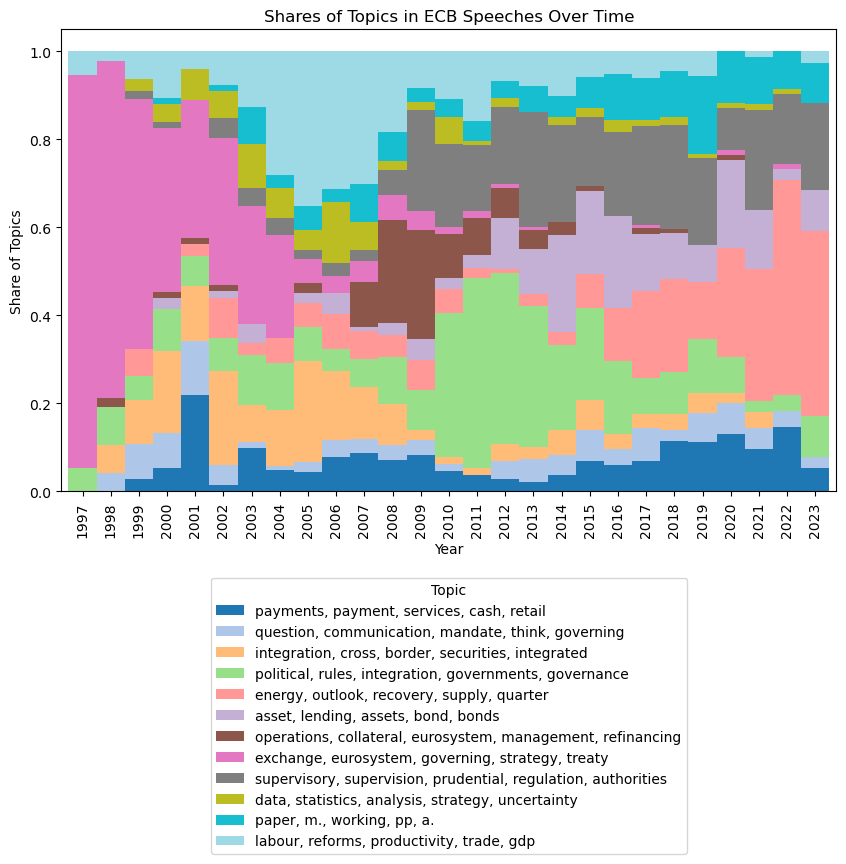

In [44]:
# Define the topic labels based on the top words in each topic
topics = sorted(lda_model.show_topics(num_topics=12, num_words=5, formatted=False), key=lambda tup: tup[0])
topic_words = [[word[0] for word in topic[1]] for topic in topics]
topic_labels = [", ".join(words) for words in topic_words]

# Compute the counts of each topic by year
topic_counts = ecb_speeches.groupby([ecb_speeches["Date"].dt.year, "topic"]).size().unstack(fill_value=0)

# Compute the shares of each topic by year
topic_shares = topic_counts.div(topic_counts.sum(axis=1), axis=0)

# Plot the shares of topics over time
topic_shares.plot(kind="bar", stacked=True, figsize=(10, 6), width=1, colormap="tab20")

plt.xlabel("Year")
plt.ylabel("Share of Topics")
plt.title("Shares of Topics in ECB Speeches Over Time")
plt.legend(title="Topic", bbox_to_anchor=(0.5, -0.8), loc="lower center", labels=topic_labels)
plt.show()

We can see that the focus of the ECB speeches has evolved over time, with some topics becoming more prominent in certain years. For example, we can see that at the beginning, the speeches were more focused on a topic related to governance of the eurosystem. After the financial crisis of 2008, bank regulation and supervision became a prominent topic. Around 2010, many speeches were focused on the sovereign debt crisis in the euro area, and more recently, supply side issues seem to have become a prominent topic in the ECB speeches.

It can also be convenient to visualize the topics using an interactive visualization. We can use the `pyLDAvis` library to create an interactive visualization of the topics and their relationships. This can help us to better understand the structure of the topics and how they relate to each other.

In [45]:
lda_display = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(lda_display)

To assess whether we have chosen a good number of topics, we can compute the coherence score for different numbers of topics and plot the results

Training LDA model with 2 topics...


Training LDA model with 7 topics...


Training LDA model with 12 topics...


Training LDA model with 17 topics...


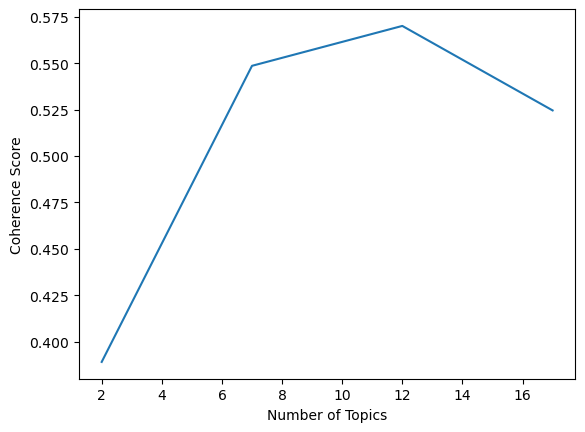

In [46]:
topics = []
score = []

for ii in [2, 7, 12, 17]:

    print(f"Training LDA model with {ii} topics...")

    # Train the LDA model with ii topics
    lda_model = LdaModel(corpus=corpus, id2word=dictionary, iterations=10, num_topics=ii, passes=10, random_state=42)

    # Compute the coherence score for the model
    # Note: Using workers=1 to avoid threading issues in Jupyter notebooks
    # The "c_v" coherence metric can be memory-intensive; use "u_mass" if you encounter issues
    cm = CoherenceModel(model=lda_model, texts=ecb_speeches["preprocessed_tokens"].to_list(), corpus=corpus, dictionary=dictionary, coherence="c_v", processes=1)

    # Append the number of topics and the coherence score to the lists
    topics.append(ii)
    score.append(cm.get_coherence())

# Plot the coherence scores for different numbers of topics
plt.plot(topics, score)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.show()

For this dataset, it looks like the coherence score is highest for around 12 topics, which is the number of topics we chose for our LDA model. However, the choice of the number of topics is not always clear-cut, and it can be helpful to also look at the interpretability of the topics when deciding on the number of topics to use.